# 05 - Cluster players (per sex)

**Input:** `data/processed/player_features.csv`, `data/processed/player_sex.csv`
**What it does:** hierarchical (Ward) clustering of players within one sex into k=3 playstyle groups, with a dendrogram and a 2D PCA projection for visualization, plus per-cluster mean feature profiles for labeling. Set `SEX` to "W" or "M" and run.
**Output:** `data/processed/player_clusters_{SEX}.csv`, `output/dendrogram_{SEX}.png`, `output/players_pca_{SEX}.png`, `output/cluster_profiles_{SEX}.csv`

Per-sex because clustering all 35 players together tracks the men's-vs-women's divide (physical), not playstyle.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
## CONFIG -- set SEX to "W" or "M"
SEX = "W"
assert SEX in ("M", "W")

N_CLUSTERS = 3
LINKAGE_METHOD = "ward"

## tactical feature subset (excludes pct_serve, rally-length-when-lost, win-rate)
CLUSTER_FEATURES = [
    "pct_smash", "pct_attacking", "pct_defensive", "pct_net", "pct_neutral",
    "mean_depth_from_center", "mean_displacement_applied",
    "mean_rally_length_when_won", "pct_wins_by_winner", "landing_x_std",
]

PROC_DIR = "data/processed"
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"clustering for SEX={SEX}")

clustering for SEX=W


## Load features and filter to one sex

In [4]:
features_full = pd.read_csv(os.path.join(PROC_DIR, "player_features.csv"), index_col="player_name")
player_sex = pd.read_csv(os.path.join(PROC_DIR, "player_sex.csv")).set_index("player_name")

print("rows before sex filter:", len(features_full))
features_full = features_full.join(player_sex)
features_full = features_full[features_full["sex"] == SEX]
print("rows after sex filter:", len(features_full))

n_strokes = features_full["n_strokes"]
features = features_full[CLUSTER_FEATURES].copy()
print("features used:", list(features.columns))

rows before sex filter: 35
rows after sex filter: 13
features used: ['pct_smash', 'pct_attacking', 'pct_defensive', 'pct_net', 'pct_neutral', 'mean_depth_from_center', 'mean_displacement_applied', 'mean_rally_length_when_won', 'pct_wins_by_winner', 'landing_x_std']


## Standardize and cluster (Ward linkage, cut at k=3)

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
print("standardized matrix shape:", X.shape)

Z = linkage(X, method=LINKAGE_METHOD)
cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

clusters = pd.DataFrame({
    "player_name": features.index,
    "cluster": cluster_labels,
    "n_strokes": n_strokes.values,
})
print("cluster sizes:")
print(clusters["cluster"].value_counts().sort_index())

standardized matrix shape: (13, 10)
cluster sizes:
cluster
1    8
2    2
3    3
Name: count, dtype: int64


## Players by cluster (sanity check against known playstyles)

In [6]:
for c in sorted(clusters["cluster"].unique()):
    members = clusters[clusters["cluster"] == c].sort_values("n_strokes", ascending=False)
    print(f"\nCluster {c} (n={len(members)} players):")
    for _, row in members.iterrows():
        print(f"  {row['player_name']:30s}  (n_strokes={row['n_strokes']})")


Cluster 1 (n=8 players):
  An Se Young                     (n_strokes=3884)
  Akane YAMAGUCHI                 (n_strokes=3099)
  PUSARLA V. Sindhu               (n_strokes=1560)
  Pornpawee CHOCHUWONG            (n_strokes=1073)
  Supanida KATETHONG              (n_strokes=985)
  Busanan ONGBAMRUNGPHAN          (n_strokes=924)
  Gregoria Mariska TUNJUNG        (n_strokes=459)
  Aakarshi KASHYAP                (n_strokes=406)

Cluster 2 (n=2 players):
  CHEN Yufei                      (n_strokes=4106)
  WANG Zhi Yi                     (n_strokes=675)

Cluster 3 (n=3 players):
  HE Bingjiao                     (n_strokes=2512)
  Carolina MARIN                  (n_strokes=1592)
  Ratchanok INTANON               (n_strokes=1228)


## Cluster profiles (mean feature values -> how we label each cluster)

In [7]:
features_with_cluster = features.copy()
features_with_cluster["cluster"] = cluster_labels
cluster_profiles = features_with_cluster.groupby("cluster").mean().round(3)
print(cluster_profiles.T)
cluster_profiles.to_csv(os.path.join(OUT_DIR, f"cluster_profiles_{SEX}.csv"))

cluster                           1        2        3
pct_smash                     0.074    0.055    0.090
pct_attacking                 0.031    0.028    0.047
pct_defensive                 0.163    0.238    0.167
pct_net                       0.231    0.289    0.276
pct_neutral                   0.358    0.241    0.263
mean_depth_from_center      101.980   90.025  101.506
mean_displacement_applied   170.072  156.504  148.022
mean_rally_length_when_won    9.353   10.855    9.066
pct_wins_by_winner            0.323    0.279    0.317
landing_x_std               174.418  151.858  147.562


## Dendrogram

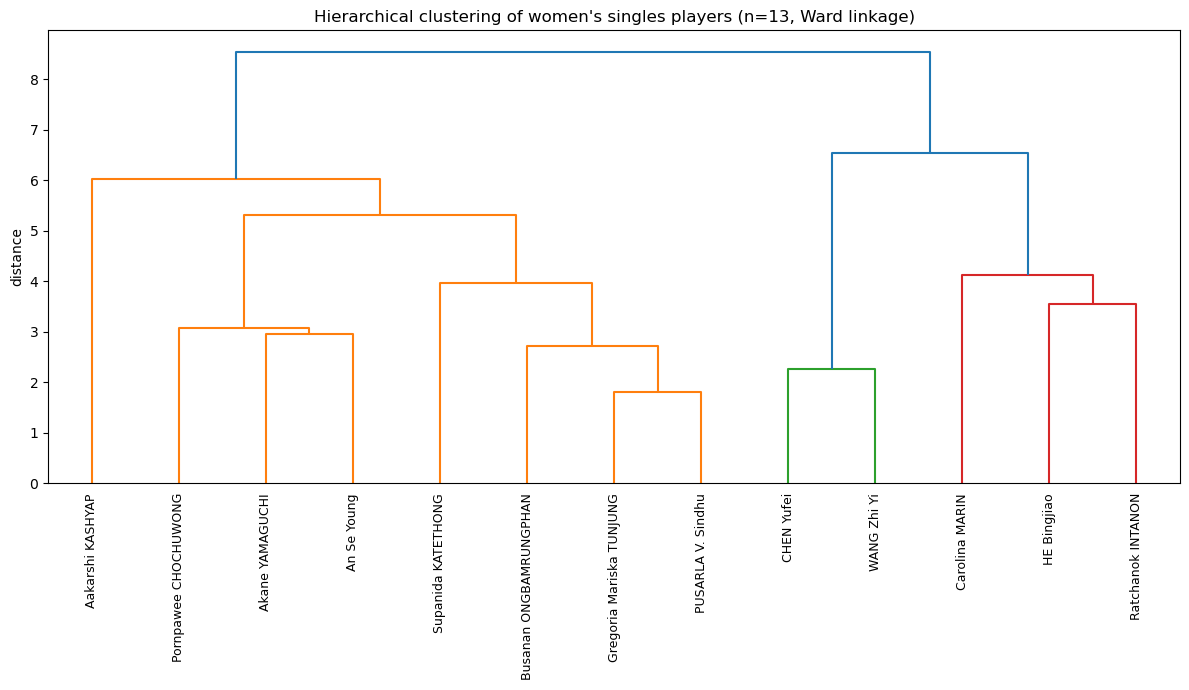

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))
dendrogram(Z, labels=features.index.tolist(), leaf_rotation=90, leaf_font_size=9,
           color_threshold=Z[-(N_CLUSTERS - 1), 2], ax=ax)
sex_label = "men's" if SEX == "M" else "women's"
ax.set_title(f"Hierarchical clustering of {sex_label} singles players (n={len(features)}, Ward linkage)")
ax.set_ylabel("distance")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"dendrogram_{SEX}.png"), dpi=150)
plt.show()

## 2D PCA projection colored by cluster

PCA explained variance: PC1=40.45%, PC2=23.80% (combined 64.25%)


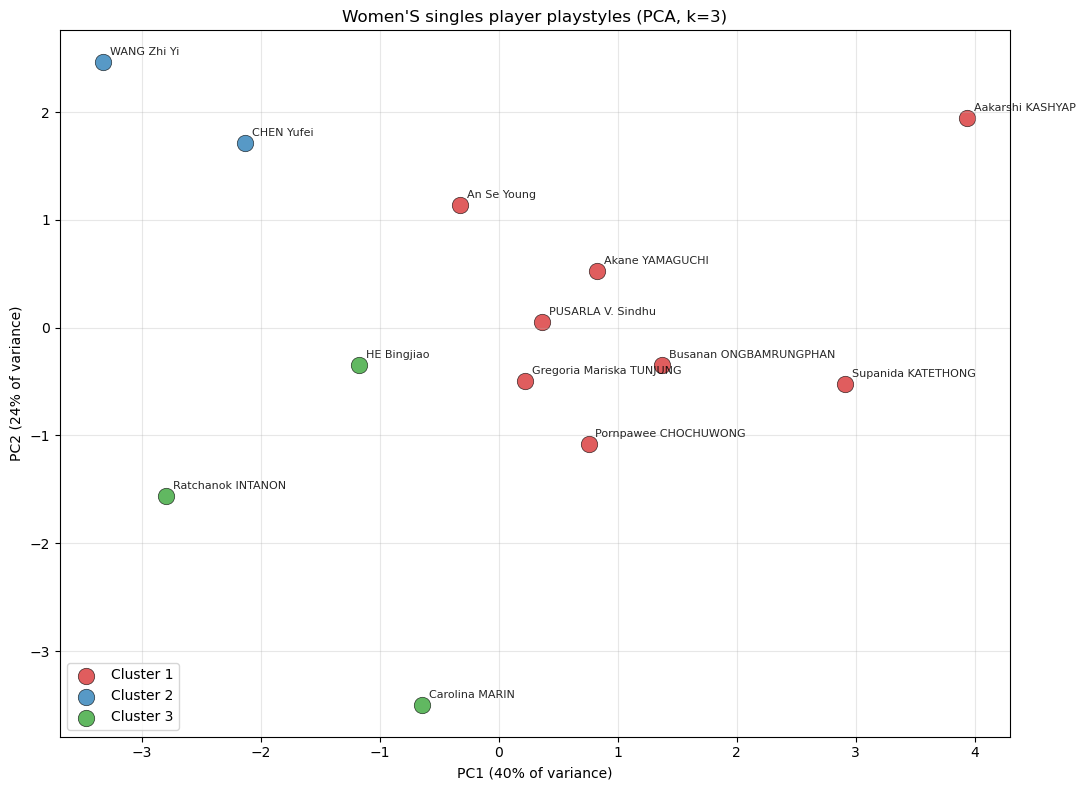

                              PC1    PC2
pct_smash                   0.143 -0.411
pct_attacking              -0.188 -0.443
pct_defensive              -0.349  0.331
pct_net                    -0.408 -0.006
pct_neutral                 0.432  0.051
mean_depth_from_center      0.317  0.016
mean_displacement_applied   0.391  0.236
mean_rally_length_when_won -0.103  0.527
pct_wins_by_winner          0.162 -0.385
landing_x_std               0.424  0.202


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%} (combined {explained.sum():.2%})")

fig, ax = plt.subplots(figsize=(11, 8))
colors = ["#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd"]
for c in sorted(clusters["cluster"].unique()):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=140, alpha=0.75, c=colors[c - 1],
               label=f"Cluster {c}", edgecolor="black", linewidth=0.5)
    for i, name in enumerate(features.index):
        if mask[i]:
            ax.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.85,
                        xytext=(5, 5), textcoords="offset points")
ax.set_xlabel(f"PC1 ({explained[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({explained[1]:.0%} of variance)")
ax.set_title(f"{sex_label.title()} singles player playstyles (PCA, k={N_CLUSTERS})")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"players_pca_{SEX}.png"), dpi=150)
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features.columns)
print(loadings.round(3))

## Save cluster assignments

In [10]:
clusters["sex"] = SEX
out_clusters_path = os.path.join(PROC_DIR, f"player_clusters_{SEX}.csv")
clusters.to_csv(out_clusters_path, index=False)
print("saved:", out_clusters_path, f"({len(clusters)} {sex_label} players, {N_CLUSTERS} clusters)")

saved: data/processed/player_clusters_W.csv (13 women's players, 3 clusters)
